In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MEXICO CRIME DATASET ANALYSIS

**Title:** Mexican Crime Statistics: Comprehensive Incident Dataset

**Subtitle:** An Extensive Compilation of Criminal Incidents in Mexico, Sourced from Official Government Data

**Source:** Official Mexican Government Website

**Description:** This dataset is a compilation of criminal incidents reported across Mexico. It includes detailed records of various criminal activities, offering insights into crime patterns and trends in different regions. The dataset is ideal for analysis in criminology, public policy, and data science.

A dataset is provided by Kaggle: https://www.kaggle.com/datasets/elanderos/official-crime-stats-mexico-2015-2023

## Reading and size

In [3]:
# Read the dataset
crime_data = pd.read_csv("data/mexico_crime.csv")

In [4]:
crime_data

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0
...,...,...,...,...,...,...,...,...,...
332411,2022,32,Zacatecas,Other legal interests affected (from common law),Counterfeiting,Forgery,Forgery,December,8
332412,2022,32,Zacatecas,Other legal interests affected (from common law),Environmental crimes,Environmental crimes,Against the environment,December,1
332413,2022,32,Zacatecas,Other legal interests affected (from common law),Crimes committed by public officials,Crimes committed by public servants,Crimes committed by public servants,December,20
332414,2022,32,Zacatecas,Other legal interests affected (from common law),Electoral crimes,Electoral crimes,Electoral crimes,December,0


In [5]:
crime_data.sample(10)

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,count
147706,2017,4,Campeche,Life and bodily integrity,Feminicide,Feminicide,With another element,June,0
26460,2023,15,México,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,156
309133,2015,19,Nuevo León,Heritage or property,Robbery,Motor Vehicle Theft,4-wheel car theft With violence,December,39
136379,2022,16,Michoacán de Ocampo,Heritage or property,Robbery,Bank Institution Robbery,With violence,May,1
23989,2022,21,Puebla,Heritage or property,Extortion,Extortion,Extortion,January,8
105612,2021,22,Querétaro,Heritage or property,Robbery,Cattle Theft,Without violence,April,22
257480,2016,4,Campeche,Sexual freedom and security,Sexual harassment,Sexual Bullying,Sexual bullying,October,0
167863,2023,17,Morelos,Society,Other crimes against society,Other crimes against society,Other crimes against society,June,1
310865,2016,5,Coahuila de Zaragoza,Life and bodily integrity,Injuries,Intentional Injury,With firearm,December,2
43519,2019,29,Tlaxcala,Life and bodily integrity,Homicide,Manslaughter,With another element,February,0


In [6]:
# See the dataset size
crime_data.shape

(332416, 9)

**SIZE: 
332 416 rows & 9 columns**

## Columns - types and meanings

In [7]:
crime_data.columns

Index(['year', 'entity_code', 'entity', 'affected_legal_good', 'type_of_crime',
       'subtype_of_crime', 'modality', 'month', 'count'],
      dtype='object')

The columns are well-written in a snake_case pattern without spelling errors.

### Features Types

In [8]:
crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332416 entries, 0 to 332415
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   year                 332416 non-null  int64 
 1   entity_code          332416 non-null  int64 
 2   entity               332416 non-null  object
 3   affected_legal_good  332416 non-null  object
 4   type_of_crime        332416 non-null  object
 5   subtype_of_crime     332416 non-null  object
 6   modality             332416 non-null  object
 7   month                332416 non-null  object
 8   count                332416 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 22.8+ MB


In [9]:
# Check for NaN values in the columns.
crime_data.isnull().sum()

year                   0
entity_code            0
entity                 0
affected_legal_good    0
type_of_crime          0
subtype_of_crime       0
modality               0
month                  0
count                  0
dtype: int64

I suppose that some features can be converted into the 'category' type. This will be done successively in the analysis for each feature which allows this modification.
There are no NaN values.

### Variable Optimization

Now let's look at the variables one by one and see what can be done for optimization

In [10]:
# Function for bar chart visualization
def create_bar_chart(title, values, y_label, x_fig_size, y_fig_size, title_fontsize, ticks_fontsize, label_fontsize):
    plt.figure(figsize = (x_fig_size, y_fig_size))
    plt.xticks(fontsize = ticks_fontsize)
    plt.yticks(fontsize = ticks_fontsize)
    plt.title(title, fontsize = title_fontsize)
    plt.barh(values.index, values.values * 100)
    plt.xlabel("Percentage", fontsize = label_fontsize)
    plt.ylabel(y_label, fontsize = label_fontsize)
    plt.show()

The charts created with the function written above, represent a categorical frequency distribution of some features such as 'type_of_crime', 'subtype_of_crime' and 'modality'. Since these variables are discrete categories rather than continuous measurements, the distribution is visualized with a bar chart. Each bar’s length corresponds to the proportion of cases.

#### Year

Meaning: The year when the crime was reported. This is a numeric field representing the calendar year (e.g., 2015).

In [11]:
crime_data.year.unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [12]:
crime_data.year.value_counts()

year
2015    37632
2016    37632
2017    37632
2018    37632
2019    37632
2020    37632
2021    37632
2022    37632
2023    31360
Name: count, dtype: int64

The years range from 2015 to 2023 but as in the description of the column is written that this is a numeric field. That is why, it is of type integer. However, for the purposes of my analysis I will convert it to type 'category'.

In [13]:
crime_data.year = crime_data.year.astype("category")

#### Entity Code

Meaning:  A numeric code representing a specific entity (state or region) within Mexico. Each number corresponds to a unique entity.

In [14]:
crime_data["entity_code"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

This means that there are 32 states or regions mentioned. The next variable 'entity' will show if everything is correct in the dataset.

In [15]:
crime_data["entity_code"].dtype

dtype('int64')

The entity code can be a categorical variable because states and regions are unique objects and do not represent quantity as well as their codes.

In [16]:
crime_data["entity_code"] = crime_data["entity_code"].astype("category")

In [17]:
crime_data["entity_code"].value_counts()

entity_code
1     10388
2     10388
3     10388
4     10388
5     10388
6     10388
7     10388
8     10388
9     10388
10    10388
11    10388
12    10388
13    10388
14    10388
15    10388
16    10388
17    10388
18    10388
19    10388
20    10388
21    10388
22    10388
23    10388
24    10388
25    10388
26    10388
27    10388
28    10388
29    10388
30    10388
31    10388
32    10388
Name: count, dtype: int64

Each state/region is mentioned exactly 10 388 times.

#### Entity

Meaning: The name of the Mexican state or region where the crime occurred. This is a textual field (e.g., Aguascalientes).

In [18]:
crime_data.entity.nunique()

32

There are 32 names of states/regions which matches the amount of entity codes.

In [19]:
crime_data.entity.unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila de Zaragoza', 'Colima', 'Chiapas',
       'Chihuahua', 'Ciudad de México', 'Durango', 'Guanajuato',
       'Guerrero', 'Hidalgo', 'Jalisco', 'México', 'Michoacán de Ocampo',
       'Morelos', 'Nayarit', 'Nuevo León', 'Oaxaca', 'Puebla',
       'Querétaro', 'Quintana Roo', 'San Luis Potosí', 'Sinaloa',
       'Sonora', 'Tabasco', 'Tamaulipas', 'Tlaxcala',
       'Veracruz de Ignacio de la Llave', 'Yucatán', 'Zacatecas'],
      dtype=object)

In [20]:
# Convert 'entity' to type 'category' as well
crime_data.entity = crime_data.entity.astype("category")

In [21]:
crime_data.entity.value_counts()

entity
Aguascalientes                     10388
Baja California                    10388
Baja California Sur                10388
Campeche                           10388
Chiapas                            10388
Chihuahua                          10388
Ciudad de México                   10388
Coahuila de Zaragoza               10388
Colima                             10388
Durango                            10388
Guanajuato                         10388
Guerrero                           10388
Hidalgo                            10388
Jalisco                            10388
Michoacán de Ocampo                10388
Morelos                            10388
México                             10388
Nayarit                            10388
Nuevo León                         10388
Oaxaca                             10388
Puebla                             10388
Querétaro                          10388
Quintana Roo                       10388
San Luis Potosí                    10388
Sinaloa  

Each state/region is mentioned exactly 10 388 times such as the entity codes so I suppose that there are no simple typing mistakes between entity code and name (for example one unique code for 2 states/regions).

#### Affected Legal Goods

Meaning: A categorical field describing the broad category of the legal good (i.e., personal or societal interest) affected by the crime. Examples include 'Personal freedom' and 'Sexual freedom and security'.

In [22]:
# As it is mentioned that the feature is categorical, I can convert it from object to type 'category'.
crime_data["affected_legal_good"] = crime_data["affected_legal_good"].astype("category") 

# Number of categories
print("Unique categories count: ")
crime_data["affected_legal_good"].nunique()

Unique categories count: 


7

Now let's look at what is most impacted by crime:

In [23]:
value_counts = crime_data["affected_legal_good"].value_counts(normalize = True)
value_counts

affected_legal_good
Heritage or property                                0.428571
Life and bodily integrity                           0.244898
Other legal interests affected (from common law)    0.102041
Personal freedom                                    0.081633
Sexual freedom and security                         0.071429
The family                                          0.040816
Society                                             0.030612
Name: proportion, dtype: float64

And this is heritage or property...

In [24]:
crime_data["affected_legal_good"].describe()

count                   332416
unique                       7
top       Heritage or property
freq                    142464
Name: affected_legal_good, dtype: object

With 142,464 cases, approximately 43% of the affected legal goods are related to heritage or property.
A histogram illustrating the distribution of affected legal goods is provided below.

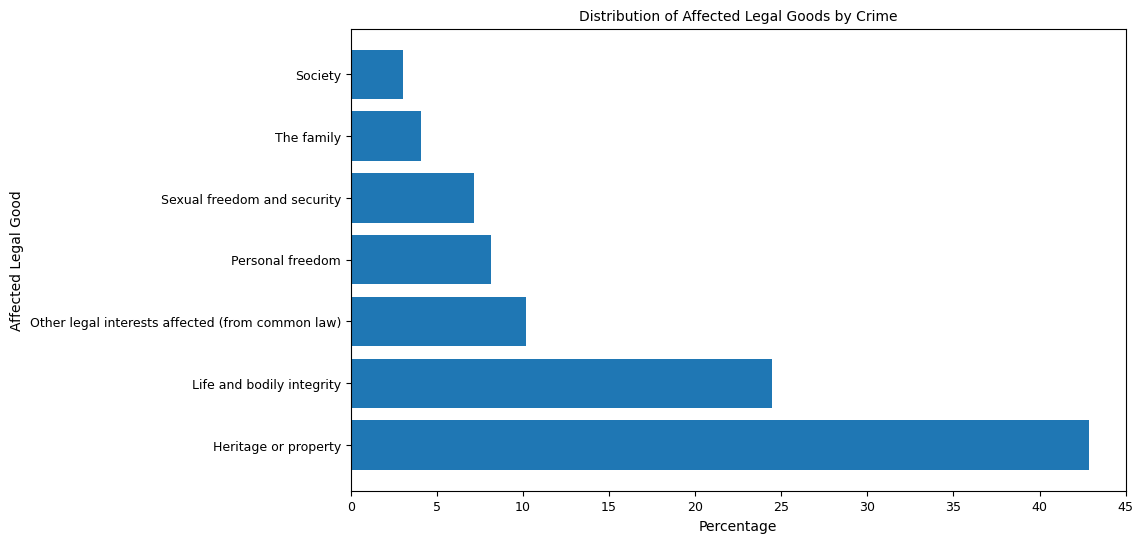

In [25]:
create_bar_chart("Distribution of Affected Legal Goods by Crime", value_counts, "Affected Legal Good", 10, 6, 10, 9, 10)

Bad news is that life and bodily integrity possesses a significant proportion - almost 25%. In terms of Maths, it is not a lot, but in terms of humanity - it is.

#### Type of Crime

Meaning: A categorical field indicating the general type of crime. This field is more specific than 'affected_legal_good' but less specific than 'subtype_of_crime'. Examples include 'Abduction', 'Sexual abuse', and 'Robbery'.

In [26]:
# Since it is mentioned in the description that 'type_of_crime' is a categorial feature, I convert it to such.
crime_data["type_of_crime"] = crime_data["type_of_crime"].astype("category")

In [27]:
# Unique values
crime_data["type_of_crime"].unique()

['Homicide', 'Injuries', 'Feminicide', 'Abortion', 'Other crimes against life and bodily integrity', ..., 'Counterfeiting', 'Environmental crimes', 'Crimes committed by public officials', 'Electoral crimes', 'Other common law crimes']
Length: 39
Categories (39, object): ['Abduction', 'Abortion', 'Aggravated rape', 'Burglary', ..., 'Sexual abuse', 'Sexual harassment', 'Simple rape', 'Threats']

In [28]:
# Crimes are grouped into 39 categories.
# Let's see their distribution...
crime_type_value_counts = crime_data["type_of_crime"].value_counts(dropna = False, normalize = True)
crime_type_value_counts

type_of_crime
Robbery                                                                0.367347
Homicide                                                               0.091837
Injuries                                                               0.091837
Kidnapping                                                             0.051020
Feminicide                                                             0.040816
Sexual harassment                                                      0.020408
Abduction                                                              0.010204
Counterfeiting                                                         0.010204
Corruption of minors                                                   0.010204
Child trafficking                                                      0.010204
Burglary                                                               0.010204
Aggravated rape                                                        0.010204
Abortion                  

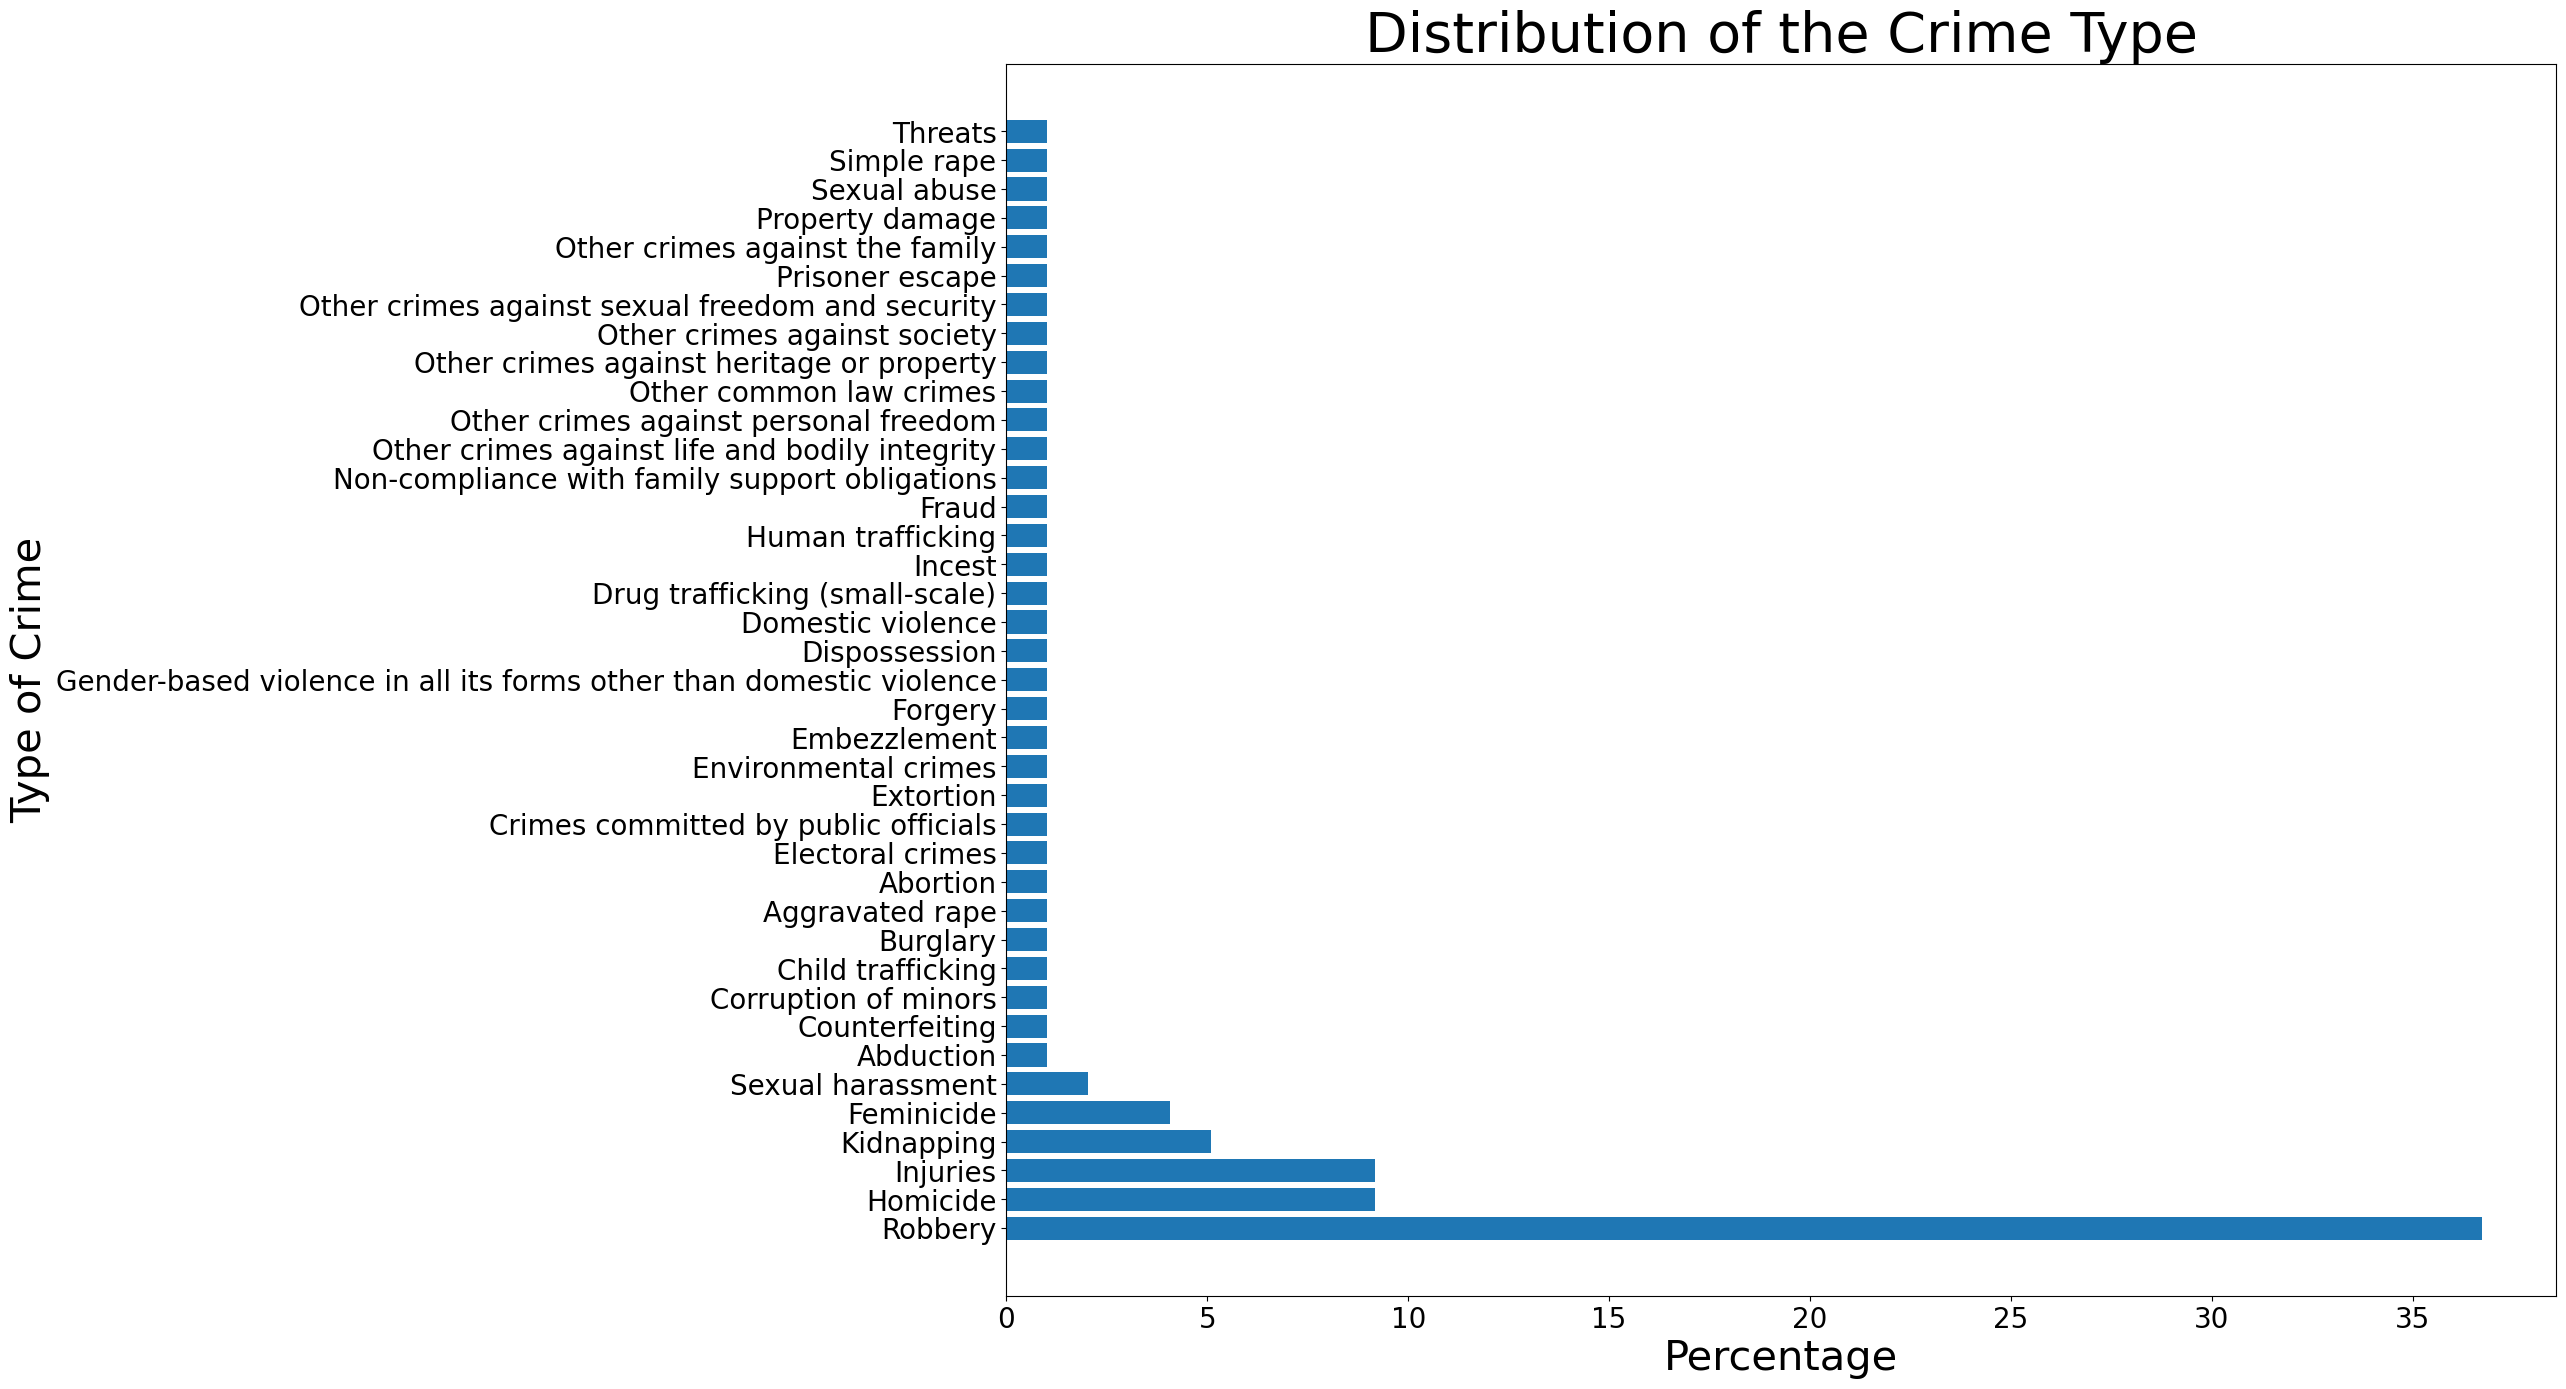

In [29]:
create_bar_chart("Distribution of the Crime Type", crime_type_value_counts, "Type of Crime", 20, 16, 40, 20, 30)

#### Subtype of Crime

Meaning: A further categorization of the type of crime. This field provides more specific details within the general type of crime. Examples include 'Sexual Harassment', 'Simple Rape', and 'Home Burglary'.

In [30]:
crime_data["subtype_of_crime"].nunique()

55

In [31]:
crime_subtype_value_counts = crime_data["subtype_of_crime"].value_counts(dropna = False, normalize = True)
crime_subtype_value_counts

subtype_of_crime
Motor Vehicle Theft                                            0.061224
Machinery Theft                                                0.061224
Unintentional Injury                                           0.051020
Kidnapping                                                     0.051020
Manslaughter                                                   0.051020
Intentional Injury                                             0.040816
Feminicide                                                     0.040816
Intentional Homicide                                           0.040816
Carrier Theft                                                  0.020408
Home Burglary                                                  0.020408
Street Robbery                                                 0.020408
Individual Public Transport Robbery                            0.020408
Public Transportation Robbery                                  0.020408
Public Space Robbery                           

An interesting fact about the columns 'type_of_crime' and 'subtype_of_crime' is that some of the values are exactly twice bigger than other ones.
For example subtypes such as Auto Parts Theft and Business Robbery take 2,0408% which is exactly 2 times bigger than 1,0204% which represents the part that Family Violence and Extortion take.

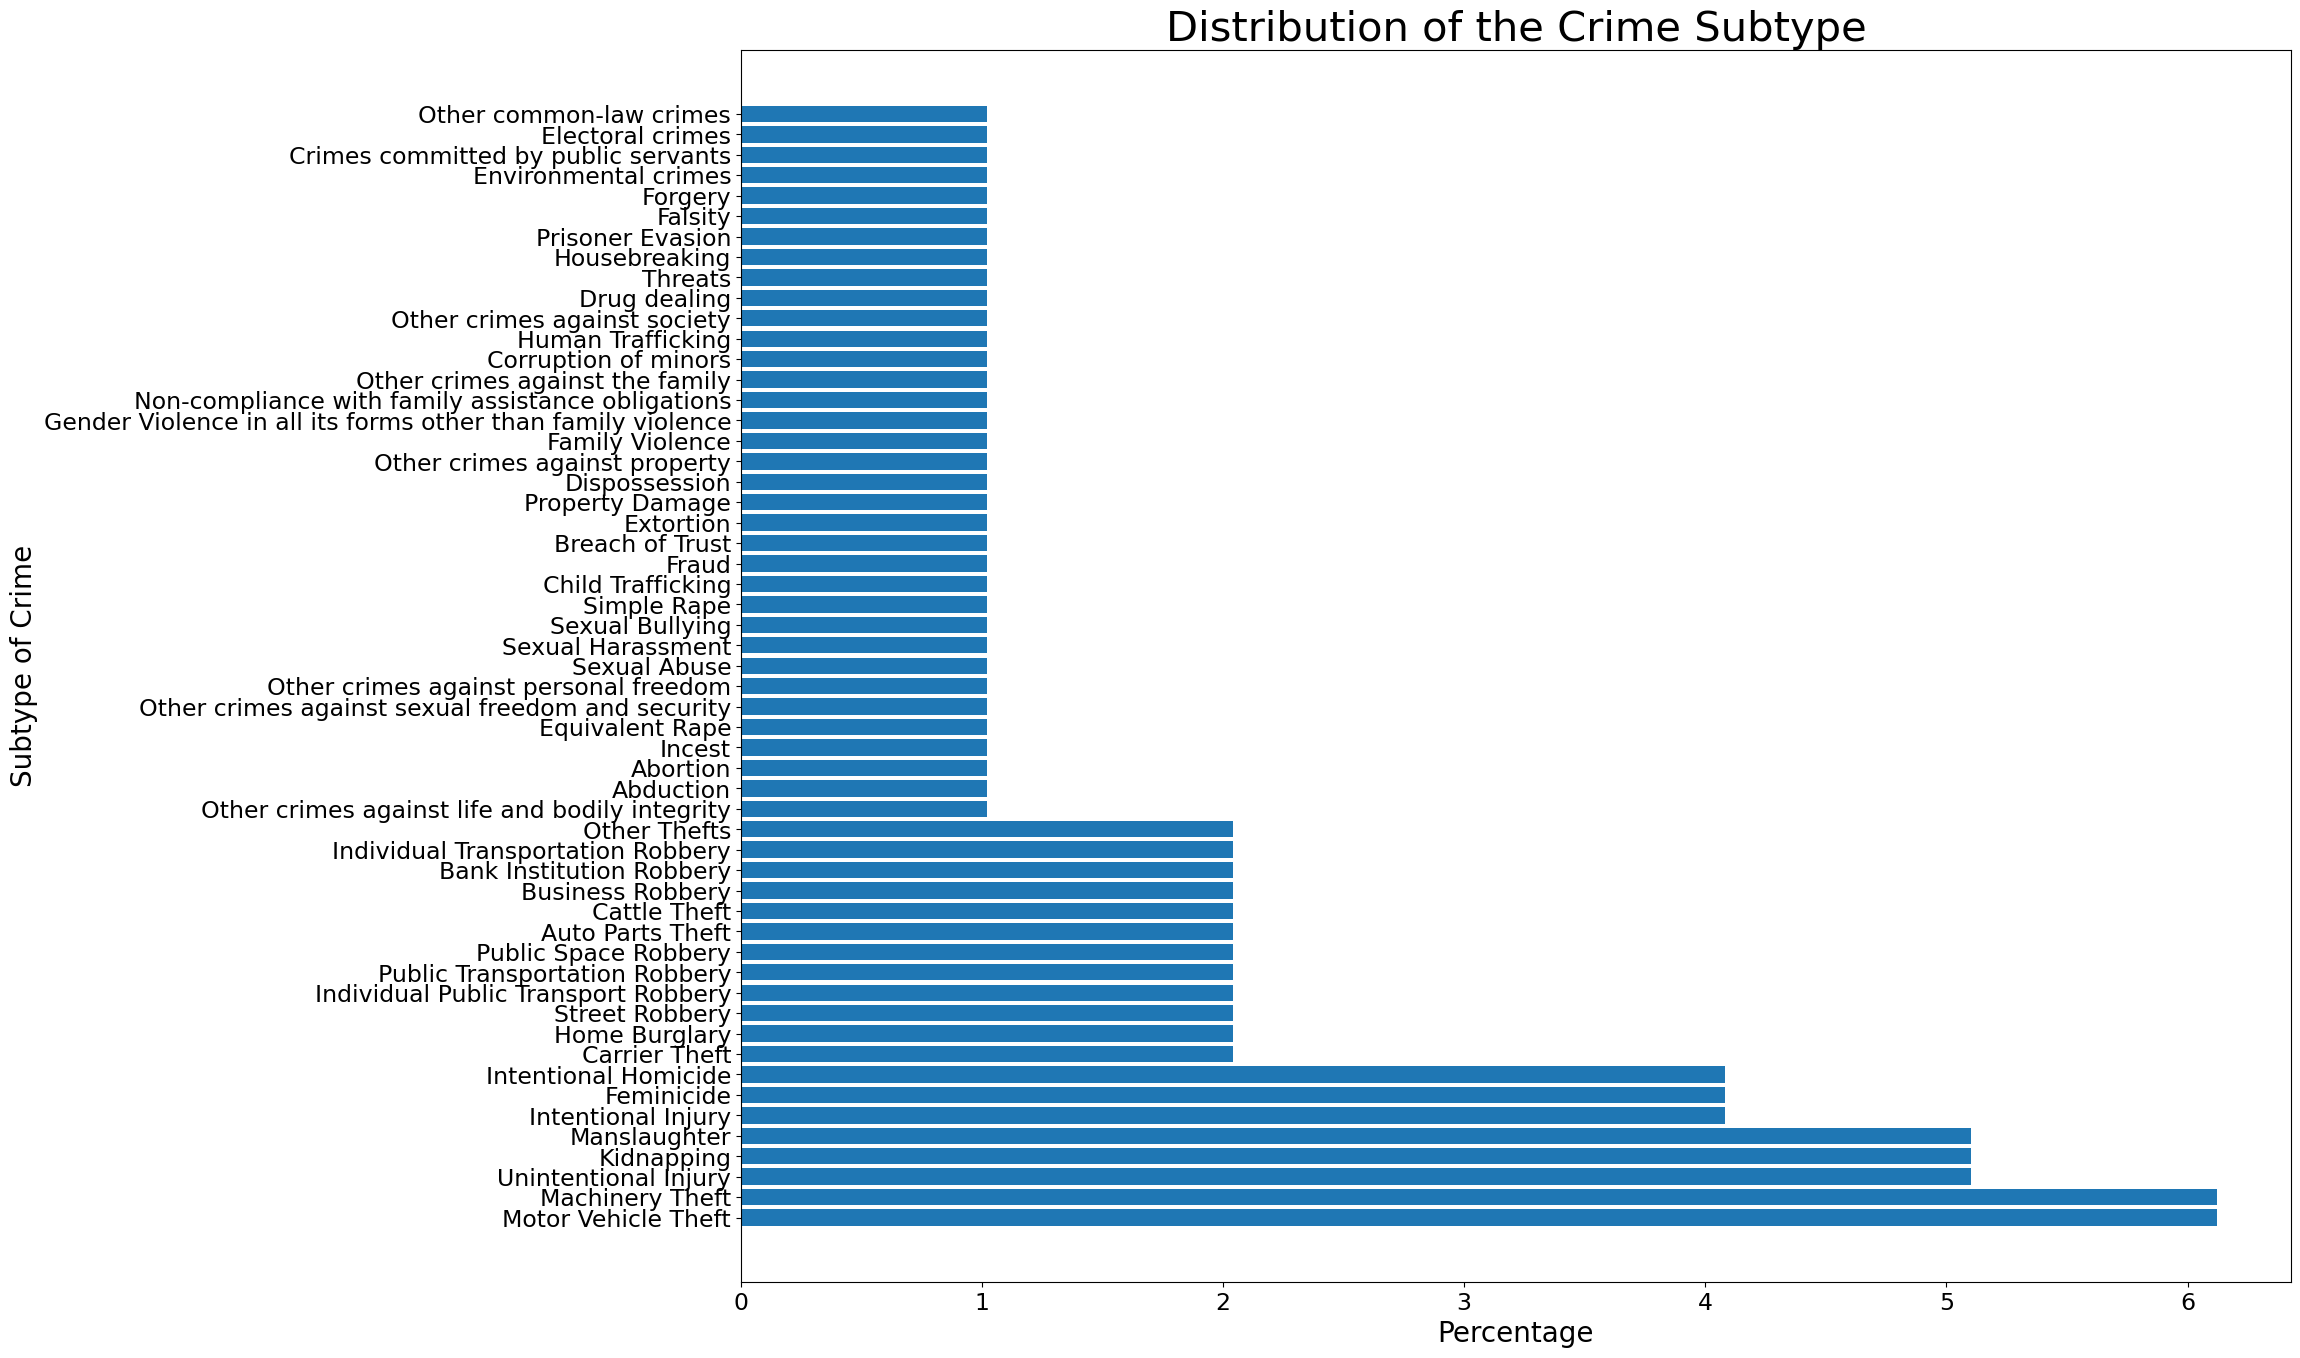

In [32]:
create_bar_chart("Distribution of the Crime Subtype", crime_subtype_value_counts, "Subtype of Crime", 20, 16, 30, 17, 20)

In [33]:
# This feature can be converted to type 'category' as well.
crime_data["subtype_of_crime"] = crime_data["subtype_of_crime"].astype("category")

#### Modality

Meaning: The specific nature or method of the crime. This field details how the crime was committed or any specific characteristic that differentiates it within its subtype. Examples include 'With violence', 'Without violence', 'Sexual Bullying'.

In [34]:
crime_modality_value_counts = crime_data.modality.value_counts(dropna = False)
crime_modality_value_counts

modality
Without violence                                                                  40704
With violence                                                                     40704
With firearm                                                                      16960
Not specified                                                                     16960
With another element                                                              16960
With sharp weapon                                                                 16960
In traffic accident                                                                6784
Extortion kidnapping                                                               3392
Kidnapping with hostage taking                                                     3392
Abortion                                                                           3392
Other crimes against life and bodily integrity                                     3392
Express kidnapping     

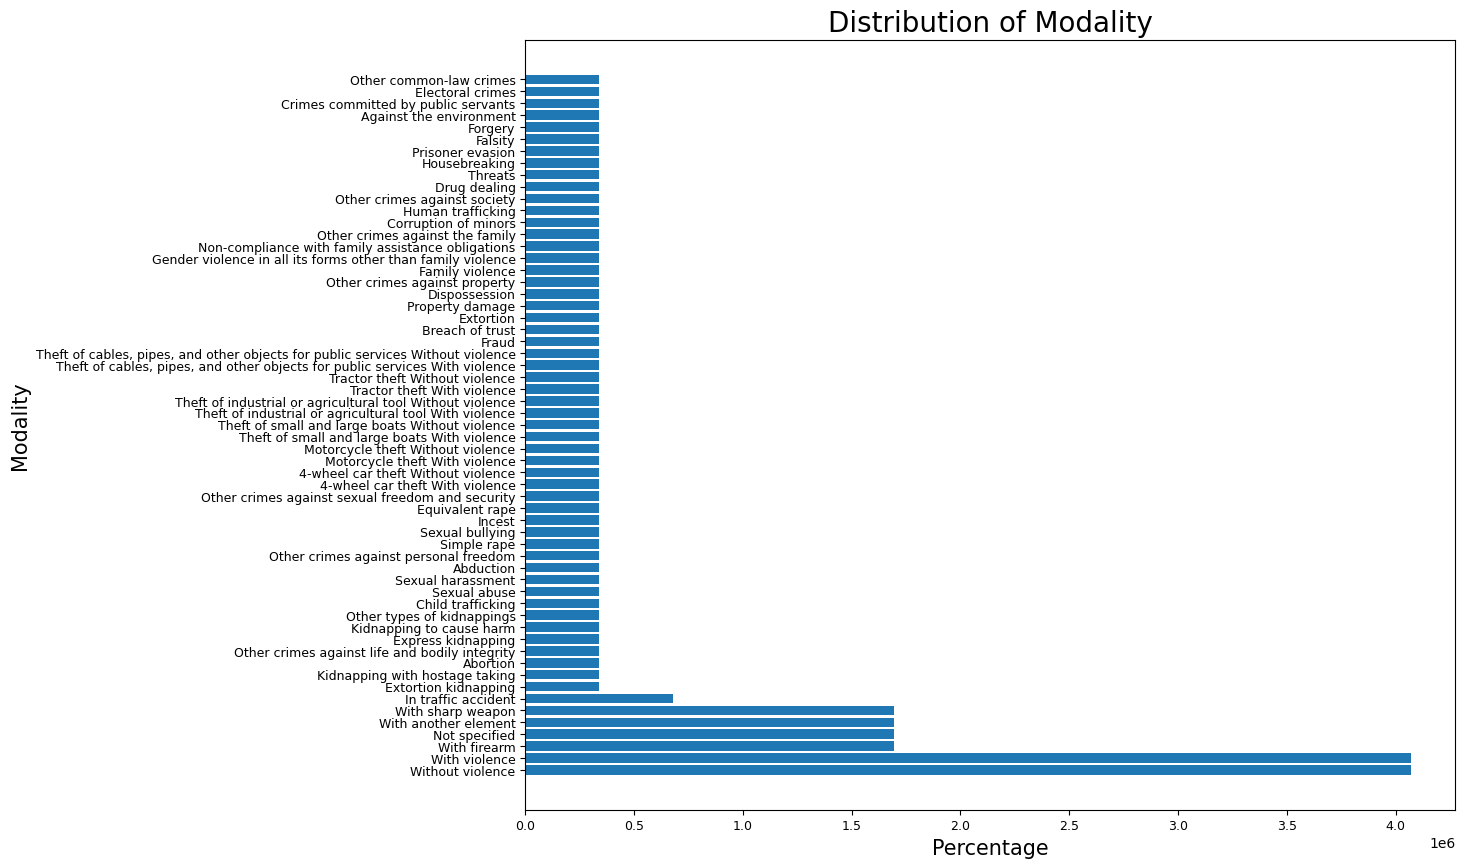

In [35]:
create_bar_chart("Distribution of Modality", crime_modality_value_counts, "Modality", 12, 10, 20, 9, 15)

In [36]:
crime_data.modality.nunique()

59

In [37]:
# Modality can also be converted to variable of type 'category'.
crime_data.modality = crime_data.modality.astype("category")

#### Month

Meaning: The month when the crime was reported. This is a textual field representing the month (e.g., January).

In [38]:
crime_data.month.value_counts()

month
January      28224
February     28224
March        28224
April        28224
May          28224
June         28224
July         28224
August       28224
September    28224
October      28224
November     25088
December     25088
Name: count, dtype: int64

There is data for all months in the period 2015-2023 except for November and December.
The description on Kaggles approves this: Date Range: 2015-2023 ( up to October) Nov - Dec not release yet.

In [39]:
crime_data.month.dtype.name

'object'

In [40]:
# Since months can be accepted for categories, I can convert the variable 'month' from object to category type.
crime_data.month = crime_data.month.astype("category")

#### Count

Meaning: The number of reported incidents for the specific crime type, subtype, and modality in the given entity and month. This is a numeric field.

In [41]:
crime_data["count"]

0           3
1           1
2           0
3           2
4           0
         ... 
332411      8
332412      1
332413     20
332414      0
332415    122
Name: count, Length: 332416, dtype: int64

I will keep the feature as a numeric value since count is a numerical discrete variable. 
The only modification that I intend to make is to rename this feature because "count" is a keyword in Python and this undefinetely will lead to mistakes or confusion.

In [42]:
crime_data.rename(columns={"count": "crime_cases_count"}, inplace=True)

## More Data Exploration

Let's see some data for example for one year.

In [43]:
crime_data.loc[crime_data.year == 2015]

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,crime_cases_count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0
...,...,...,...,...,...,...,...,...,...
310459,2015,32,Zacatecas,Other legal interests affected (from common law),Counterfeiting,Forgery,Forgery,December,4
310460,2015,32,Zacatecas,Other legal interests affected (from common law),Environmental crimes,Environmental crimes,Against the environment,December,0
310461,2015,32,Zacatecas,Other legal interests affected (from common law),Crimes committed by public officials,Crimes committed by public servants,Crimes committed by public servants,December,6
310462,2015,32,Zacatecas,Other legal interests affected (from common law),Electoral crimes,Electoral crimes,Electoral crimes,December,1


From the table above I can see that for each year, all 32 entities are written again and again. May be it is good to create some pivot tables for better visualization.

Let's pick up one state and see the data.

In [44]:
crime_data.loc[(crime_data.year == 2015) & (crime_data.entity == "Aguascalientes")]

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,crime_cases_count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0
...,...,...,...,...,...,...,...,...,...
307421,2015,1,Aguascalientes,Other legal interests affected (from common law),Counterfeiting,Forgery,Forgery,December,19
307422,2015,1,Aguascalientes,Other legal interests affected (from common law),Environmental crimes,Environmental crimes,Against the environment,December,0
307423,2015,1,Aguascalientes,Other legal interests affected (from common law),Crimes committed by public officials,Crimes committed by public servants,Crimes committed by public servants,December,0
307424,2015,1,Aguascalientes,Other legal interests affected (from common law),Electoral crimes,Electoral crimes,Electoral crimes,December,0


For every threesome: [type of crime, subtype of crime, modality] the year and entity are repeated.

That is why, I will need pivoting quite often. Pivot tables are a great way to visualize data with values in some columns that are repeated.

## Simple Analysis - Questions

### Question 1: Which is the most dangerous state/region in Mexico?

In [45]:
entities_total_crime_cases = crime_data.pivot_table(index = "entity", values = "crime_cases_count", aggfunc = "sum", observed = "False")
entities_total_crime_cases = entities_total_crime_cases.sort_values(by = "crime_cases_count", ascending = False)
print(entities_total_crime_cases)

                                 crime_cases_count
entity                                            
México                                     3142428
Ciudad de México                           1891445
Jalisco                                    1213139
Guanajuato                                 1113954
Baja California                             948561
Nuevo León                                  760247
Veracruz de Ignacio de la Llave             632438
Chihuahua                                   604505
Puebla                                      587892
Coahuila de Zaragoza                        483516
Tabasco                                     468865
Querétaro                                   465974
Hidalgo                                     394697
Morelos                                     393261
San Luis Potosí                             380649
Michoacán de Ocampo                         375757
Tamaulipas                                  368350
Quintana Roo                   

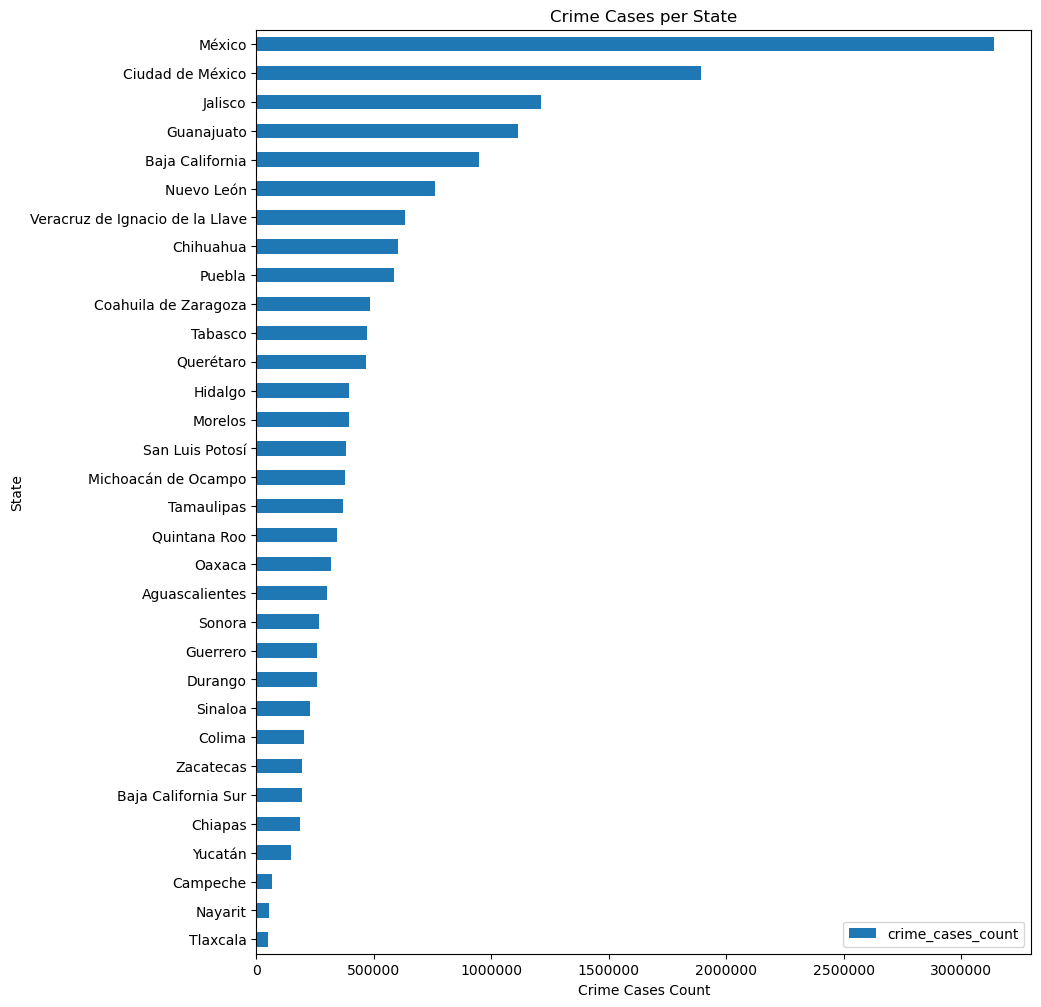

In [46]:
entities_total_crime_cases.plot(kind='barh', figsize=(10,12))
plt.title("Crime Cases per State")
plt.xlabel("Crime Cases Count")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

#### Answer: The most dangerous state is Mèxico with more than 3 000 000 crime cases for the years from 2015 to 2023 (excluding November and December 2023).

#### Distribution of the crime cases per year in Mèxico

In [47]:
mexico_state = crime_data.loc[crime_data.entity == "México", ["year", "crime_cases_count", "type_of_crime", "subtype_of_crime", "affected_legal_good"]]
mexico_state

,year,crime_cases_count,type_of_crime,subtype_of_crime,affected_legal_good
1372,2015,107,Homicide,Intentional Homicide,Life and bodily integrity
1373,2015,13,Homicide,Intentional Homicide,Life and bodily integrity
1374,2015,47,Homicide,Intentional Homicide,Life and bodily integrity
1375,2015,0,Homicide,Intentional Homicide,Life and bodily integrity
1376,2015,0,Homicide,Manslaughter,Life and bodily integrity
...,...,...,...,...,...
330745,2022,192,Counterfeiting,Forgery,Other legal interests affected (from common law)
330746,2022,34,Environmental crimes,Environmental crimes,Other legal interests affected (from common law)
330747,2022,349,Crimes committed by public officials,Crimes committed by public servants,Other legal interests affected (from common law)
330748,2022,0,Electoral crimes,Electoral crimes,Other legal interests affected (from common law)


In [48]:
mexico_state_years = mexico_state.groupby("year")["crime_cases_count"].sum().reset_index()
mexico_state_years

C:\Users\aneli\AppData\Local\Temp\ipykernel_11388\3082941913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mexico_state_years = mexico_state.groupby("year")["crime_cases_count"].sum().reset_index()


,year,crime_cases_count
0,2015,323525
1,2016,325038
2,2017,345693
3,2018,341028
4,2019,354602
5,2020,341278
6,2021,389492
7,2022,397513
8,2023,324259


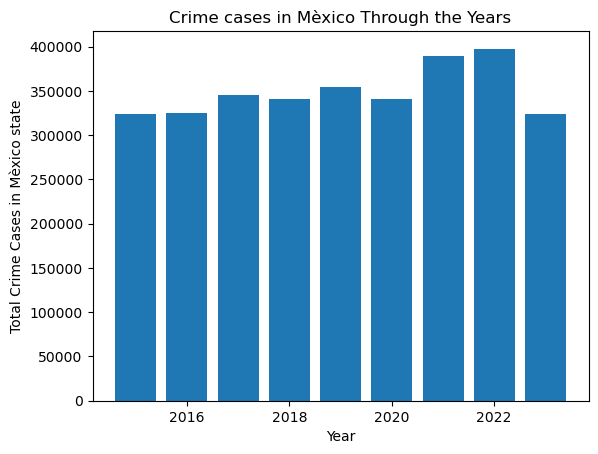

In [49]:
plt.bar(mexico_state_years["year"], mexico_state_years["crime_cases_count"])
plt.xlabel("Year")
plt.ylabel("Total Crime Cases in Mèxico state")
plt.title("Crime cases in Mèxico Through the Years")
plt.show()

Conclusion from this bar chart: 2022 is the year with most crime cases in Mèxico - 397 513 cases, followed by 2021. It seems that these two years form the peak of crimes in Mèxico state.

#### Most Often Type of Crime in Mèxico state

In [50]:
mexico_state_type_crime = mexico_state.groupby("type_of_crime")["crime_cases_count"].sum().reset_index().sort_values(by = "crime_cases_count", ascending = False)
mexico_state_type_crime

C:\Users\aneli\AppData\Local\Temp\ipykernel_11388\991542421.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mexico_state_type_crime = mexico_state.groupby("type_of_crime")["crime_cases_count"].sum().reset_index().sort_values(by = "crime_cases_count", ascending = False)


,type_of_crime,crime_cases_count
34,Robbery,1324749
25,Other common law crimes,604150
22,Injuries,514575
9,Domestic violence,123688
33,Property damage,115817
17,Fraud,82293
8,Dispossession,35396
19,Homicide,30305
7,Crimes committed by public officials,30222
12,Embezzlement,30062


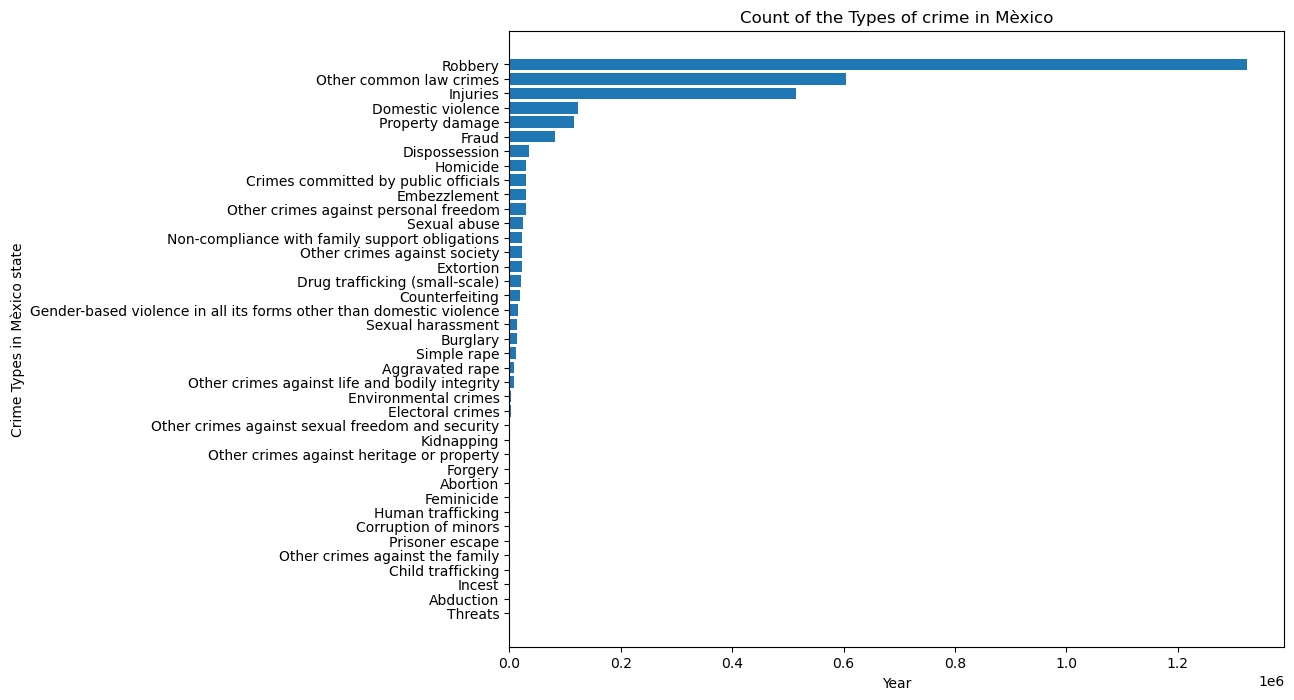

In [51]:
plt.figure(figsize = (10, 8))
plt.barh(mexico_state_type_crime["type_of_crime"], mexico_state_type_crime["crime_cases_count"])
plt.xlabel("Year")
plt.ylabel("Crime Types in Mèxico state")
plt.gca().invert_yaxis()
plt.title("Count of the Types of crime in Mèxico")
plt.show()

The most wide-spread type of crime in the state of Mèxico is Robbery. Some crime types sich as child trafficking have not been commited in Mèxico state.

In [52]:
mexico_state_subtype_crime = mexico_state.groupby("subtype_of_crime")["crime_cases_count"].sum().reset_index().sort_values(by = "crime_cases_count", ascending = False)
mexico_state_subtype_crime

C:\Users\aneli\AppData\Local\Temp\ipykernel_11388\3634471344.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mexico_state_subtype_crime = mexico_state.groupby("subtype_of_crime")["crime_cases_count"].sum().reset_index().sort_values(by = "crime_cases_count", ascending = False)


,subtype_of_crime,crime_cases_count
37,Other common-law crimes,604150
30,Intentional Injury,381629
34,Motor Vehicle Theft,374213
36,Other Thefts,324371
52,Street Robbery,179195
5,Business Robbery,144817
54,Unintentional Injury,132946
18,Family Violence,123688
45,Property Damage,115817
21,Fraud,82293


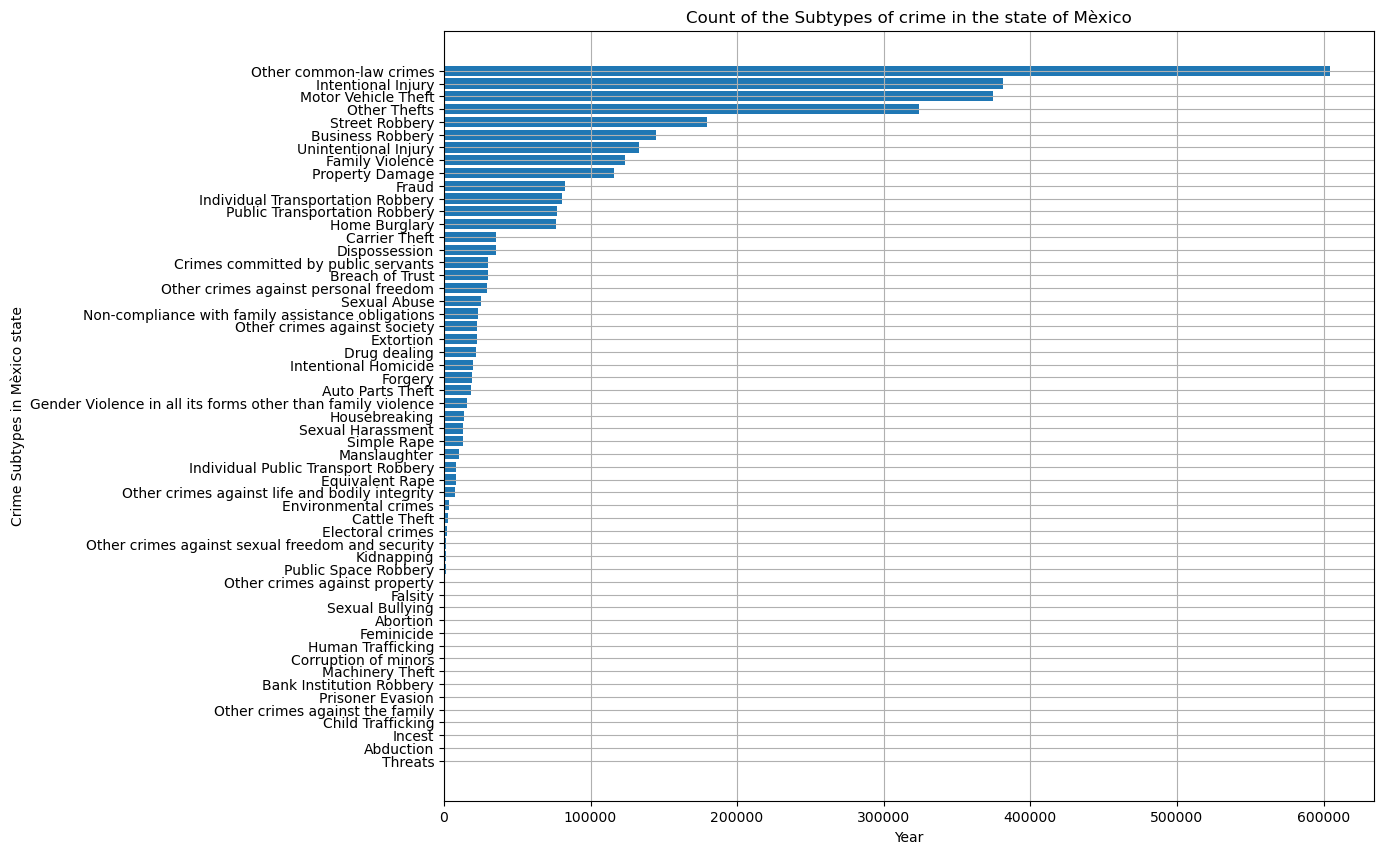

In [68]:
plt.figure(figsize = (12, 10))
plt.barh(mexico_state_subtype_crime["subtype_of_crime"], mexico_state_subtype_crime["crime_cases_count"])
plt.gca().invert_yaxis()
plt.grid(True)
plt.title("Count of the Subtypes of crime in the state of Mèxico")
plt.xlabel("Year")
plt.ylabel("Crime Subtypes in Mèxico state")
plt.show()

In [54]:
mexico_state_affected_good = mexico_state.groupby("affected_legal_good")["crime_cases_count"].sum().reset_index().sort_values(by = "crime_cases_count", ascending = False)
mexico_state_affected_good

C:\Users\aneli\AppData\Local\Temp\ipykernel_11388\2939275351.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mexico_state_affected_good = mexico_state.groupby("affected_legal_good")["crime_cases_count"].sum().reset_index().sort_values(by = "crime_cases_count", ascending = False)


,affected_legal_good,crime_cases_count
0,Heritage or property,1611814
2,Other legal interests affected (from common law),696070
1,Life and bodily integrity,554504
6,The family,162662
4,Sexual freedom and security,61940
3,Personal freedom,30897
5,Society,24541


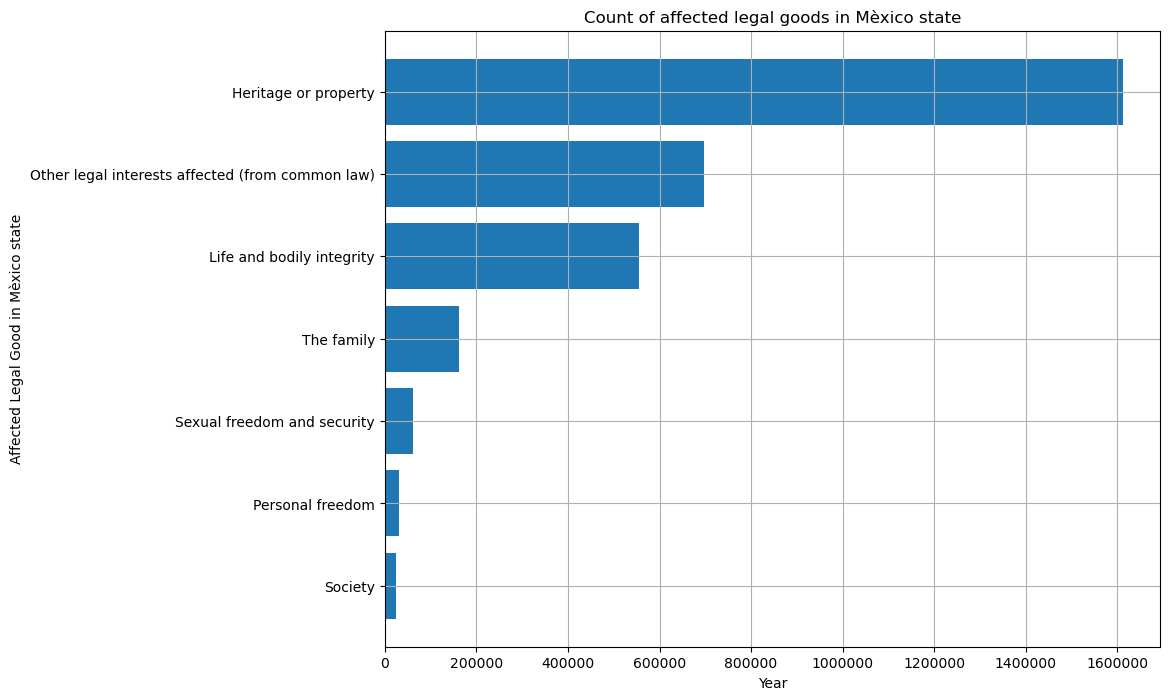

In [66]:
plt.figure(figsize = (10, 8))
plt.barh(mexico_state_affected_good["affected_legal_good"], mexico_state_affected_good["crime_cases_count"])
plt.gca().invert_yaxis()
plt.ticklabel_format(style='plain', axis='x') 
plt.grid(True)
plt.title("Count of affected legal goods in Mèxico state")
plt.xlabel("Year")
plt.ylabel("Affected Legal Good in Mèxico state")
plt.show()

Heritage or propery is the most affected legal good in the state of Mèxico.

### Question 2: Distribution of the Amount of Crime Cases in the Country of Mexico

In [56]:
crime_count_per_year = crime_data.pivot_table(index = "year", values = "crime_cases_count", aggfunc = "sum")
crime_count_per_year

C:\Users\aneli\AppData\Local\Temp\ipykernel_11388\770311386.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  crime_count_per_year = crime_data.pivot_table(index = "year", values = "crime_cases_count", aggfunc = "sum")


,crime_cases_count
year,
2015,1657804
2016,1764179
2017,1939497
2018,1989935
2019,2071179
2020,1841191
2021,2044256
2022,2141979
2023,1839920


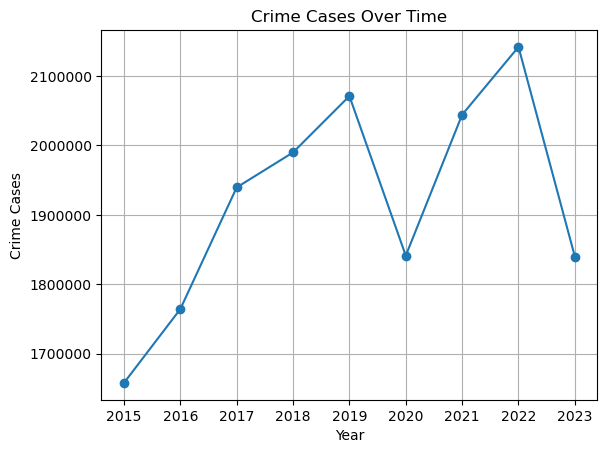

In [64]:
plt.plot(crime_count_per_year.index, crime_count_per_year.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Crime Cases")
plt.title("Crime Cases Over Time")
plt.ticklabel_format(style='plain', axis='y') 
plt.grid(True)
plt.show()


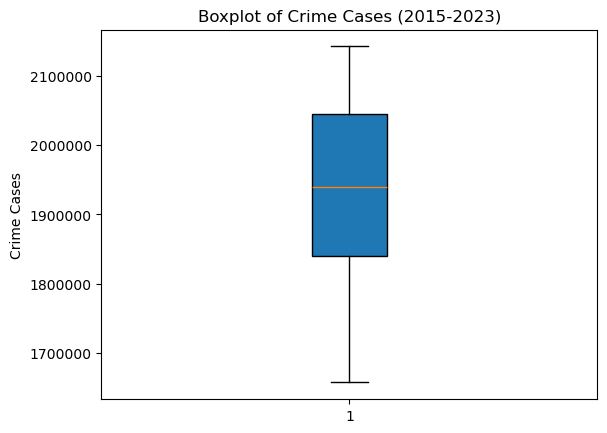

In [59]:
crime_cases = crime_count_per_year.values.ravel()
plt.boxplot(crime_cases, vert=True, patch_artist=True)
plt.ylabel("Crime Cases")
plt.ticklabel_format(style='plain', axis='y')
plt.title("Boxplot of Crime Cases (2015-2023)")
plt.show()

Years can be numerical values such as the crime count. There are no outliers.

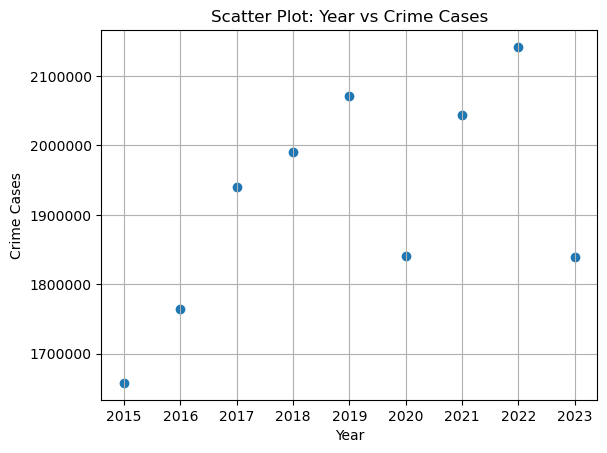

In [76]:
plt.scatter(crime_count_per_year.index, crime_count_per_year.values)
plt.xlabel("Year")
plt.ylabel("Crime Cases")
plt.title("Scatter Plot: Year vs Crime Cases")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.show()


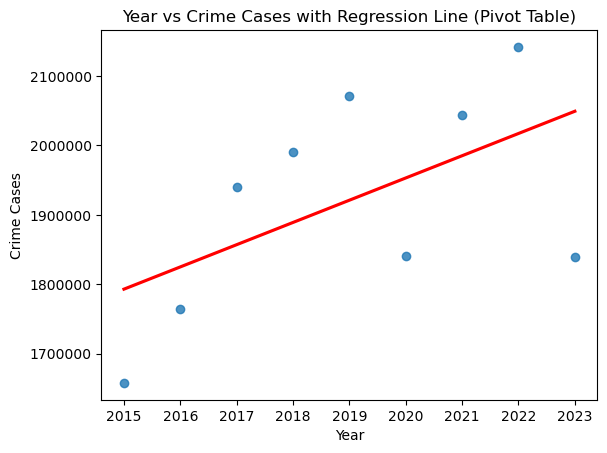

In [77]:
import seaborn as sns

sns.regplot(
    x=crime_count_per_year.index, 
    y=crime_count_per_year["crime_cases_count"], 
    ci=None, 
    line_kws={"color": "red"}
)
plt.ticklabel_format(style='plain', axis='y')
plt.title("Year vs Crime Cases with Regression Line (Pivot Table)")
plt.xlabel("Year")
plt.ylabel("Crime Cases")
plt.show()

In [80]:
from scipy.stats import pearsonr
crime_count_per_year.index = crime_count_per_year.index.astype(int)
years = crime_count_per_year.index.values


corr, p_value = pearsonr(years, crime_cases)
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.5571389908633216
P-value: 0.11915065030702372


In [78]:
print(crime_count_per_year.corr())   # Correlation between year and cases


                   crime_cases_count
crime_cases_count                1.0


In [81]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = crime_count_per_year.index.values.reshape(-1,1)
y = crime_count_per_year["crime_cases_count"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))


Slope: 32043.96666666667
Intercept: -62775664.25555556
R^2: 0.31040385514019586


In [90]:
from scipy.stats import pearsonr, spearmanr

X = crime_data.year.astype(int)
y = crime_data["crime_cases_count"]

pearson_corr, _ = pearsonr(X, y)
spearman_corr, _ = spearmanr(X, y)

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)


Pearson correlation: 0.01886431439170512
Spearman correlation: 0.04653630487916423
